# JobFit Phase A: post-test quality optimization (development only)

This notebook is the visual source of truth for Phase A. It reads the artifacts in `evals/results/quality_optimization/` and never computes a model call. Every number on this page comes from those files, so the page stays correct as experiments are added.

**Claim boundary.** Phase A is *post-test development optimization*. It is not an improved held-out result. CP2.4 (D-087, D-088) is locked: its labels, workbook, results and the held-out CVs CV3-CV5 are never read here (D-089). Whether a Phase A winner generalizes needs a new fresh test set.

**Flow:** frozen baseline -> development weaknesses -> hypotheses -> prompt variants -> controlled development evaluation -> failure analysis -> best-quality challenger -> confirmation -> conclusion.

Each experiment section follows: **Why, Hypothesis, Experiment setup, Result, What it means, Decision, Next.**

## 0. Setup and leakage check

In [1]:
import json
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT), str(ROOT / 'src')]
os.environ.setdefault('MPLCONFIGDIR', '/tmp/jobfit_mplconfig')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jobfit.eval import qa_phase_a as qa

QA = qa.QA_DIR
for path in QA.rglob('*'):
    qa.dev_path(path)  # raises LeakageError if anything here points at CP2.4 material

def load(exp, name):
    p = QA / exp / name
    return json.loads(p.read_text()) if p.exists() else None

registry = pd.DataFrame(qa.load_registry())
numeric = ['p_at_5', 'ndcg_at_10', 'macro_f1', 'quote_validity', 'hallucination_count', 'unsupported_positive_count',
           'schema_failure_count', 'repair_count', 'hold_rate', 'fallback_count', 'run_to_run_agreement',
           'total_cost_usd', 'cost_per_pair', 'median_latency', 'p95_latency', 'sample_count']
for c in numeric:
    registry[c] = pd.to_numeric(registry[c], errors='coerce')
completed = registry[registry['status'].isin(['completed', 'rejected', 'finalist', 'selected'])]
print('Leakage check: OK. Experiments registered:', len(registry), '| with results:', len(completed))

Leakage check: OK. Experiments registered: 10 | with results: 5


## 1. Why optimize?

**Why:** CP2.4 showed the frozen pipeline works on the held-out CVs, but that test cannot be used again for choices. The development data shows where the pipeline still makes mistakes, and Phase A asks whether a better evidence-matching prompt reduces them without hurting grounding.

The current pipeline is the D-087 freeze: Hybrid Qwen stage 1, seniority rule, top K = 10, DeepSeek extraction, GPT-6 Sol evidence matching (prompt v1.1, quote-check v1.1, G1/G2), H2v2 holds, PARTIAL weight 0.5, experience block, product order.

In [2]:
base_cfg = load('QA-E00-BASELINE', 'config.json')
show = ['pipeline_version', 'model', 'prompt_file', 'prompt_version', 'prompt_sha256', 'schema', 'validator', 'guardrails',
        'retrieval', 'k', 'partial_weight', 'seniority_rule', 'experience_rule', 'hold_policy', 'freeze', 'cv_count']
display(pd.Series({k: base_cfg[k] for k in show}, name='QA-E00-BASELINE').to_frame())
display(pd.DataFrame(base_cfg['datasets']).T)

,QA-E00-BASELINE
pipeline_version,pipeline-cp23-freeze-candidate-v4
model,gpt-6-sol
prompt_file,prompts/evidence_matching_v1_1.md
prompt_version,evidence-prompt-v1.1
prompt_sha256,19576d1940ad74015954f7014ba816f428ac835e726d89...
schema,cv-v1.1-precision
validator,quote-check-v1.1
guardrails,"[G1, G2]"
retrieval,hybrid_fts_dense_rrf
k,10


,name,cvs,pairs,matchable_pairs,labels,labels_sha256,split_file,split_sha256,units,source
ranking,QA-DEV-RANK-v1,"[CV1, CV2]",20,19,gold r4 relevance (CV1-CV2),35abd0e1bcb09e8395ba4d9d8d3a0e99086e7a648366c7...,NaN,NaN,NaN,NaN
fixed_input,QA-DEV-FI-v1,NaN,"{'optimization': 20, 'confirmation': 22}",NaN,NaN,NaN,evals/results/quality_optimization/benchmark_v...,8a6c9e73dcae31d90e88ef6b27f2054e4a396e684a269f...,"{'optimization': 411, 'confirmation': 415}",NaN
anchor,r3 fixed-input anchor,NaN,4,NaN,NaN,NaN,NaN,NaN,73,evals/results/cp23/dev_eval_v2_20261004/model_...


## 2. Baseline: QA-E00-BASELINE

**Experiment setup:** offline reproduction from saved development artifacts (no new call): the 60 saved GPT-6 Sol pairs of the D-079 coverage run, the r3 fixed-input anchor of the model sweep, and gold r4 relevance for CV1-CV2.

**Result:** the table below. The ranking numbers must equal D-086 (frozen development value); if they do not, stop.

In [3]:
bm = load('QA-E00-BASELINE', 'metrics.json')
bc = load('QA-E00-BASELINE', 'cost.json')
summary = {
    'P@5 (macro CV1-CV2)': bm['ranking']['macro_p_at_5'],
    'NDCG@10 (macro CV1-CV2)': bm['ranking']['macro_ndcg_at_10'],
    'held or unscored in analyzed top 10': f"{bm['ranking']['held_or_unscored']}/{bm['ranking']['analyzed']}",
    'quote validity (positive items)': f"{bm['grounding']['quote_validity']:.3f} of {bm['grounding']['positive_items']}",
    'anchor macro-F1 (73 units)': bm['anchor_fixed_input_r3']['macro_f1'],
    'anchor run-to-run agreement': bm['anchor_fixed_input_r3']['run_to_run_label_agreement']['rate'],
    'schema failures / repairs': f"{bm['reliability']['schema_failure_count']} / {bm['reliability']['repair_count']}",
    'cost per called pair (USD)': bc['cost_per_called_pair'],
    'median / p95 latency (s)': f"{bc['median_latency_ms']/1000:.1f} / {bc['p95_latency_ms']/1000:.1f}",
}
display(pd.Series(summary, name='QA-E00-BASELINE').to_frame())
per_cv = pd.DataFrame({cv: {k: v[k] for k in ('p_at_5', 'ndcg_at_10')} for cv, v in bm['ranking']['per_cv'].items()}).T
display(per_cv)

,QA-E00-BASELINE
P@5 (macro CV1-CV2),0.7
NDCG@10 (macro CV1-CV2),0.567344
held or unscored in analyzed top 10,4/20
quote validity (positive items),1.000 of 676
anchor macro-F1 (73 units),0.84633
anchor run-to-run agreement,0.876712
schema failures / repairs,0 / 0
cost per called pair (USD),0.027422
median / p95 latency (s),15.4 / 21.3


,p_at_5,ndcg_at_10
CV1,0.6,0.514682
CV2,0.8,0.620006


## 3. Error analysis: failure taxonomy

**Why:** prompt variants must answer real, counted errors, not guesses. Three sources, kept separate because their denominators differ:

- **A.** unit-level errors of the baseline on the reviewed r3 anchor (73 units);
- **B.** process outcomes of the 60 saved pipeline pairs (holds, unclear units, quotes);
- **C.** ranking discordance in the analyzed top 10 (relevance versus product position).

Category rules for A and C are mechanical (direction of the error plus the requirement field; position plus relevance). The short notes in C are an analyst reading to be checked by Dion.

A. 11 unit errors of 73 anchor units; run-to-run agreement 64/73


,unit,field,gold,sol,category,text
0,CV1/F00332/P30-U08,soft_skill,PARTIAL,NO_MATCH,overly_conservative_soft_skill,Learning new techniques
1,CV1/F00332/P30-U09,soft_skill,PARTIAL,NO_MATCH,overly_conservative_soft_skill,Independent learning
2,CV1/F00332/P30-U13,knowledge_area,MATCH,PARTIAL,partial_match_calibration_underclaim,SQL-based analysis
3,CV1/F00036/P09-U11,knowledge_area,PARTIAL,MATCH,adjacent_evidence_overclaim,Inferential statistics
4,CV1/F00036/P09-U12,knowledge_area,MATCH,PARTIAL,partial_match_calibration_underclaim,Research methodology
5,CV1/F00036/P09-U13,other,MATCH,PARTIAL,partial_match_calibration_underclaim,Explaining technical analysis to nontechnical ...
6,CV1/F00036/P09-U14,knowledge_area,MATCH,PARTIAL,partial_match_calibration_underclaim,Database management
7,CV1/F00036/P09-U17,soft_skill,NO_MATCH,PARTIAL,soft_skill_inference_overclaim,Attention to detail
8,CV2/F00815/P52-U07,knowledge_area,PARTIAL,MATCH,adjacent_evidence_overclaim,Data pipelines
9,CV2/F00815/P52-U14,knowledge_area,MATCH,PARTIAL,partial_match_calibration_underclaim,Testing


B. pair outcomes: {'score_final': 34, 'hold_caused_by_missing_extraction': 6, 'score_no_score': 3, 'score_on_hold': 11, 'score_provisional': 6}
   invalid quotes: 0 of 676 | responsibility units: ['F00020/U07: Responsible for preparing learning materials.', 'F00020/U08: Responsible for the learning schedule.']


,cv_id,job_id,position,relevance,score_status,score_pct,category,analyst_note
0,CV1,F00556,3,1,final,60.00,low_relevance_in_top5,Internship asks for a current student; most ot...
1,CV1,F00020,5,0,final,50.00,low_relevance_in_top5,Mentoring/teaching role outside the target fam...
2,CV1,F00366,8,2,on_hold,NaN,relevant_job_held_or_unscored,Extraction not usable (held_extraction).
3,CV1,F00022,9,3,on_hold,NaN,relevant_job_held_or_unscored,Two required units not judged (needs_clarifica...
4,CV1,F00103,10,2,on_hold,NaN,relevant_job_held_or_unscored,"One required unit not judged, so the job is on..."
5,CV2,F00645,3,1,final,69.23,low_relevance_in_top5,Required 2 years is needs_clarification and ex...
6,CV2,F00629,7,2,provisional,45.83,relevant_job_below_top5,None
7,CV2,F00176,9,2,final,26.92,relevant_job_below_top5,26 required units from one long list (over-spl...
8,CV2,F00559,10,2,no_score,NaN,relevant_job_held_or_unscored,No required unit extracted (responsibilities-o...


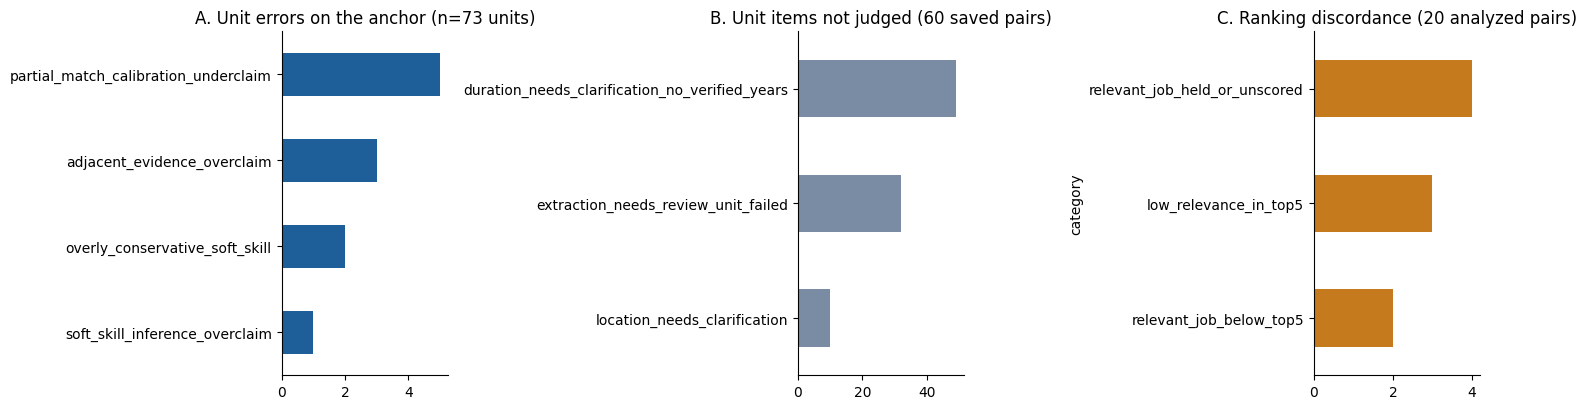

In [4]:
fx = load('QA-E00-BASELINE', 'failures.json')
a = fx['A_unit_errors_r3_anchor']
print(f"A. {a['errors']} unit errors of {a['units']} anchor units; run-to-run agreement {a['run_to_run_label_agreement']['same']}/{a['run_to_run_label_agreement']['units']}")
cat_a = pd.Series(a['by_category']).sort_values()
display(pd.DataFrame(a['examples'])[['unit', 'field', 'gold', 'sol', 'category', 'text']])
b = fx['B_process_saved_pipeline_pairs']
cat_b = pd.Series(b['non_done_items']).sort_values()
print('B. pair outcomes:', b['pair_outcomes'])
print('   invalid quotes:', b['invalid_quotes'], 'of', b['positive_items_checked'], '| responsibility units:', b['responsibility_as_qualification_units'])
c = pd.DataFrame(fx['C_ranking_discordance_top10'])
display(c)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
cat_a.plot.barh(ax=axes[0], color='#1f5f99'); axes[0].set_title(f"A. Unit errors on the anchor (n={a['units']} units)")
cat_b.plot.barh(ax=axes[1], color='#7a8ca3'); axes[1].set_title('B. Unit items not judged (60 saved pairs)')
c['category'].value_counts().sort_values().plot.barh(ax=axes[2], color='#c47a1d'); axes[2].set_title('C. Ranking discordance (20 analyzed pairs)')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); plt.show()

**What it means:** the matching prompt can only reach group A (MATCH/PARTIAL calibration in both directions, soft skills, run-to-run instability). Group B is caused by inputs and rules that Phase A keeps fixed (extraction `needs_review` units, durations without verified years, location). Most of group C is holds or job-level fit (role family, required years excluded under H2v2), which a matching prompt cannot change. So a prompt win should mainly show up in unit-level quality; a large ranking gain from a prompt alone would be suspicious.

## 4. Hypotheses (Wave 1)

| ID | Hypothesis | Evidence | Expected effect | Main risk |
| --- | --- | --- | --- | --- |
| QA-H01 | v1.1 lowers clear contextual use to PARTIAL more often than guideline B1/B2 allows. | Anchor group A: `partial_match_calibration_underclaim` | Fewer underclaims, higher MATCH recall | More overclaims and unsupported positives |
| QA-H02 | v1.1 accepts neighbouring or umbrella evidence as direct evidence, and infers soft skills. | Anchor group A: `adjacent_evidence_overclaim`, `soft_skill_inference_overclaim` | Fewer overclaims and unsupported positives | More underclaims |
| QA-H03 | Dense unordered instructions cause label instability between identical runs. | Anchor run-to-run agreement below 1 | Higher run-to-run agreement, same or better F1 | No quality change at all |

The counts behind each row are in the tables of section 3.

In [5]:
hyp = registry[['experiment_id', 'status', 'hypothesis_id', 'parent_experiment', 'prompt_file', 'prompt_sha256', 'dataset', 'sample_count', 'decision_reason']]
display(hyp)

,experiment_id,status,hypothesis_id,parent_experiment,prompt_file,prompt_sha256,dataset,sample_count,decision_reason
0,QA-E00-BASELINE,selected,QA-E00,D-087 freeze,prompts/evidence_matching_v1_1.md,19576d1940ad74015954f7014ba816f428ac835e726d89...,QA-DEV-RANK-v1 (20 pairs) + r3 anchor (73 units),20,No challenger eligible under selection_rule_v2...
1,QA-E00-FI-R1,completed,QA-E00,QA-E00-BASELINE,prompts/evidence_matching_v1_1.md,19576d1940ad74015954f7014ba816f428ac835e726d89...,QA-DEV-FI-v1 optimization,20,Baseline v1.1 on the optimization subset; R1 v...
2,QA-E00-FI-R2,completed,QA-E00,QA-E00-FI-R1,prompts/evidence_matching_v1_1.md,19576d1940ad74015954f7014ba816f428ac835e726d89...,QA-DEV-FI-v1 optimization,20,Baseline v1.1 on the optimization subset; R1 v...
3,QA-E01,rejected,QA-H01,QA-E00-FI-R1,prompts/evidence_matching_v1_2_qa_e01.md,3fae757a2b6eb5283d05b0d157b67ed3b5e97af7d79584...,QA-DEV-FI-v1 optimization + QA-DEV-RANK-v1,39,Gates pass. Path A fails (macro-F1 0.699 < 0.7...
4,QA-E02,rejected,QA-H02,QA-E00-FI-R1,prompts/evidence_matching_v1_2_qa_e02.md,d2b362a267e18a1f1e92a27177f5f728732a89e206aa65...,QA-DEV-FI-v1 optimization + QA-DEV-RANK-v1,39,Unit gates pass; path A and path B both met (m...
5,QA-E03,withdrawn,QA-H03,QA-E00-FI-R1,prompts/evidence_matching_v1_2_qa_e03.md,8520056dddaf9ebc52bfc1c8e3f8bbf74176ed82289910...,QA-DEV-FI-v1 optimization + QA-DEV-RANK-v1,39,E01/E02 were not ambiguous for the decision (n...
6,QA-E03-R,withdrawn,QA-H03,QA-E03,prompts/evidence_matching_v1_2_qa_e03.md,8520056dddaf9ebc52bfc1c8e3f8bbf74176ed82289910...,QA-DEV-FI-v1 optimization,20,Superseded by D-089 amendment 1: the repeat is...
7,QA-E01-R2,withdrawn,QA-H01,QA-E01,prompts/evidence_matching_v1_2_qa_e01.md,3fae757a2b6eb5283d05b0d157b67ed3b5e97af7d79584...,QA-DEV-FI-v1 optimization,20,Repeat only runs for a single provisional fina...
8,QA-E02-R2,withdrawn,QA-H02,QA-E02,prompts/evidence_matching_v1_2_qa_e02.md,d2b362a267e18a1f1e92a27177f5f728732a89e206aa65...,QA-DEV-FI-v1 optimization,20,Repeat only runs for a single provisional fina...
9,QA-E03-R2,withdrawn,QA-H03,QA-E03,prompts/evidence_matching_v1_2_qa_e03.md,8520056dddaf9ebc52bfc1c8e3f8bbf74176ed82289910...,QA-DEV-FI-v1 optimization,20,Repeat only runs for a single provisional fina...


## 5. Prompt experiments

**Experiment setup (same for all):** model GPT-6 Sol with the frozen request rules, no fallback, quote-check v1.1, G1/G2, dynamic output, H2v2, weight 0.5, K 10. Only the evidence prompt changes. Each challenger keeps the v1.1 text word for word and adds one paragraph.

- **Fixed-input optimization subset (QA-DEV-FI-v1):** gold gap_v2 requirement units (CV1-CV2) as input, gold labels as the answer. A failed or unclear unit counts as wrong.
- **Ranking (QA-DEV-RANK-v1):** the 19 matchable analyzed pairs; only the order inside the top 10 can change.
- **Noise:** QA-E00-FI-R1 and R2 run the baseline twice. A difference smaller than the R1/R2 gap is noise.

In [6]:
def diff_prompt(path):
    base = (ROOT / 'prompts/evidence_matching_v1_1.md').read_text().split('\n', 1)[1].rstrip('\n')
    text = (ROOT / path).read_text()
    return text.split(base, 1)[1].strip()

for exp in ['QA-E01', 'QA-E02', 'QA-E03']:
    row = registry.set_index('experiment_id').loc[exp]
    meta = json.loads((ROOT / row['prompt_file']).with_suffix('.meta.json').read_text())
    print(f"=== {exp} ({row['hypothesis_id']}) {row['prompt_file']}  sha {row['prompt_sha256'][:12]}")
    print('Intended change:', meta['intended_change'])
    print('Added paragraph:', diff_prompt(row['prompt_file']), '\n')

=== QA-E01 (QA-H01) prompts/evidence_matching_v1_2_qa_e01.md  sha 3fae757a2b6e
Intended change: Calibrate MATCH versus PARTIAL toward guideline B1/B2 (D-042): clear contextual use in work, project, study or research is MATCH; PARTIAL only for the listed reasons.
Added paragraph: Calibration of MATCH versus PARTIAL (guideline B1, B2, D-042). Use MATCH when a CV sentence shows the required skill or knowledge being used in work, a project, study or research, with enough context to see what was done. A thesis, research project, class project or portfolio project counts as use for skill and knowledge units; it does not count as employment, production or a duration. Depth or level words in the requirement ("strong", "solid", "practical", "good understanding of") are not separate obligations: one clear example of use is MATCH. Use PARTIAL only for one of these reasons: the item appears only in a skills list or course list; only a course or certificate is shown when the JD asks for experience;

In [7]:
def fixed_metrics(exp):
    m = load(exp, 'metrics.json')
    return None if not m else m.get('fixed_input_optimization')

rows = []
for exp in ['QA-E00-FI-R1', 'QA-E00-FI-R2', 'QA-E01', 'QA-E02', 'QA-E03', 'QA-E03-R']:
    f = fixed_metrics(exp)
    if f is None:
        rows.append({'experiment': exp, 'state': 'not run yet'})
        continue
    m = load(exp, 'metrics.json')
    rows.append({'experiment': exp, 'state': 'done', 'units': f['units'], 'macro_f1': f['macro_f1'],
                 'accuracy': f['accuracy_all_units'], 'overclaim': f['overclaim'], 'underclaim': f['underclaim'],
                 'unsupported_positive': f['unsupported_positive'], 'unassessed': f['unassessed_units'],
                 'failed_pairs': len(f['failed_pairs']), 'quote_validity': m['grounding']['quote_validity'],
                 'run_to_run': (m.get('run_to_run_agreement') or {}).get('rate'),
                 'P@5': (m.get('ranking') or {}).get('macro_p_at_5'), 'NDCG@10': (m.get('ranking') or {}).get('macro_ndcg_at_10'),
                 'hold_rate': (m.get('ranking') or {}).get('hold_rate')})
wave1 = pd.DataFrame(rows).set_index('experiment')
display(wave1)

,state,units,macro_f1,accuracy,overclaim,underclaim,unsupported_positive,unassessed,failed_pairs,quote_validity,run_to_run,P@5,NDCG@10,hold_rate
experiment,,,,,,,,,,,,,,
QA-E00-FI-R1,done,411.0,0.713871,0.751825,67.0,20.0,59.0,15.0,0.0,1.0,NaN,NaN,NaN,NaN
QA-E00-FI-R2,done,411.0,0.714644,0.754258,68.0,19.0,59.0,14.0,0.0,1.0,0.92944,NaN,NaN,NaN
QA-E01,done,411.0,0.699198,0.759124,61.0,23.0,47.0,15.0,0.0,1.0,NaN,0.7,0.552747,0.2
QA-E02,done,411.0,0.739686,0.785888,40.0,33.0,37.0,15.0,0.0,1.0,NaN,NaN,NaN,NaN
QA-E03,not run yet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
QA-E03-R,not run yet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Baseline repeatability (QA-E00-FI-R1 vs QA-E00-FI-R2)

**Why:** a challenger only counts if it beats the baseline by more than the baseline differs from itself. Same prompt, same pairs, two runs: how many unit labels change, in which direction, and where.

Exact agreement 382/411 (92.9%); changed 29
Which run matches gold on the changed units: {'second_run_matches_gold': 12, 'first_run_matches_gold': 11, 'neither_matches_gold': 6}
Changed by CV: {'CV1': 8, 'CV2': 21} | by importance: {'required': 23, 'preferred': 6}


,changed,units,rate
certification,0.0,1.0,0.000000
experience_duration,0.0,14.0,0.000000
language,0.0,6.0,0.000000
skill_tool,4.0,81.0,0.049383
soft_skill,4.0,76.0,0.052632
other,1.0,12.0,0.083333
knowledge_area,17.0,203.0,0.083744
education,2.0,17.0,0.117647
location,1.0,1.0,1.000000


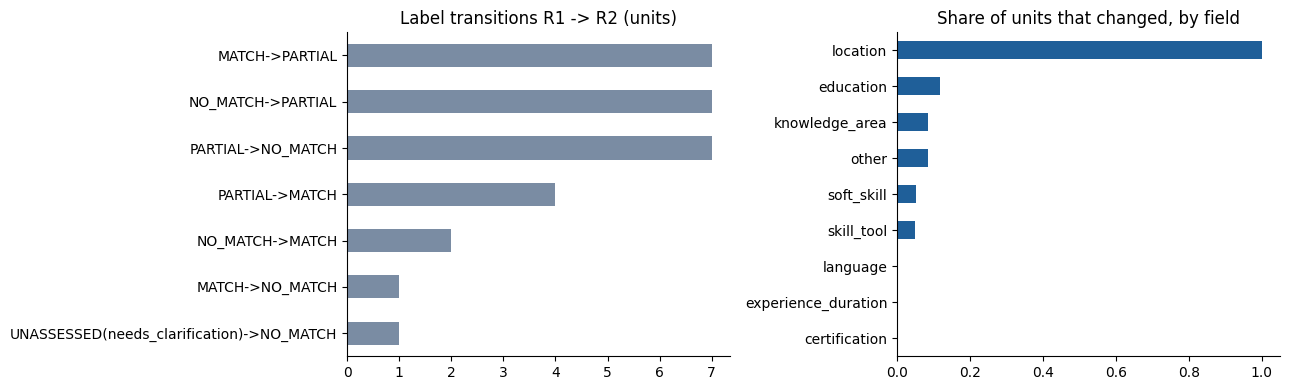

In [8]:
rep_files = sorted(p for p in (QA / 'analysis').glob('repeatability_QA-E00-FI-R1_vs_QA-E00-FI-R2_v*.json') if not p.name.endswith('.receipt.json'))
if not rep_files:
    print('Run: python scripts/qa_phase_a.py repeatability --a QA-E00-FI-R1 --b QA-E00-FI-R2')
else:
    rep = json.loads(rep_files[-1].read_text())
    print(f"Exact agreement {rep['same']}/{rep['units']} ({rep['agreement']:.1%}); changed {rep['changed']}")
    print('Which run matches gold on the changed units:', rep['which_run_matches_gold'])
    print('Changed by CV:', rep['changed_by_cv'], '| by importance:', rep['changed_by_importance'])
    tr = pd.Series(rep['transitions']).sort_values()
    fld = pd.DataFrame(rep['changed_by_field']).T.sort_values('rate')
    display(fld)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    tr.plot.barh(ax=axes[0], color='#7a8ca3'); axes[0].set_title('Label transitions R1 -> R2 (units)')
    fld['rate'].plot.barh(ax=axes[1], color='#1f5f99'); axes[1].set_title('Share of units that changed, by field')
    for ax in axes:
        ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout(); plt.show()


In [9]:
# Scorecards against the locked rule (written by `python scripts/qa_phase_a.py scorecard --exp <ID>`)
cards = {}
for p in sorted((QA / 'analysis').glob('scorecard_QA-E0*_v1.json')):
    c = json.loads(p.read_text())
    cards[c['experiment_id']] = {**{f'gate {k}': v for k, v in c['gates'].items()}, 'path_A': c['path_A'], 'path_B': c['path_B'],
                                 'no_other_regression': c['no_other_regression'], 'eligible': c['eligible'], **c['values']}
display(pd.DataFrame(cards) if cards else 'No challenger scorecard yet.')
conf_rows = {}
for exp in ['QA-E00-FI-R1', 'QA-E00-FI-R2'] + list(cards):
    m = load(exp, 'metrics.json')
    if m:
        conf = m['fixed_input_optimization']['confusion']
        conf_rows[exp] = {f'gold {g} -> {p}': v for g, row in conf.items() for p, v in row.items() if g != p}
display(pd.DataFrame(conf_rows))

# Stage A checks (amendment 2)
checks = {}
for p in sorted((QA / 'analysis').glob('stage_a_check_QA-E0*_v1.json')):
    c = json.loads(p.read_text())
    checks[c['experiment_id']] = {'decision': c['decision'], 'reasons': '; '.join(c['reasons']), **c['values']}
display(pd.DataFrame(checks) if checks else 'No Stage A check yet.')


,QA-E01
gate quote_validity_1,True
gate unsupported_not_worse,True
gate prompt_failures_not_worse,True
gate no_unrecovered_transient,True
gate ranking_p5_not_lower,True
gate ranking_ndcg_within_0_02,True
path_A,False
path_B,False
no_other_regression,True
eligible,False


,QA-E00-FI-R1,QA-E00-FI-R2,QA-E01
gold MATCH -> PARTIAL,9,9,8
gold MATCH -> NO_MATCH,1,1,2
gold MATCH -> not_assessed,1,1,1
gold PARTIAL -> MATCH,8,9,14
gold PARTIAL -> NO_MATCH,10,9,13
gold PARTIAL -> not_assessed,13,13,13
gold NO_MATCH -> MATCH,19,16,26
gold NO_MATCH -> PARTIAL,40,43,21
gold NO_MATCH -> not_assessed,1,0,1


,QA-E02
decision,stop
reasons,other regression (underclaims or unassessed un...
macro_f1,0.739686
accuracy_all_units,0.785888
unsupported_positive,37
overclaim,40
underclaim,33
unassessed_units,15


**Per experiment: Result, What it means, Decision.** The cell above is the result. The written reading and the decision for each experiment are recorded in `docs/experiments.md` and in the registry (`decision`, `decision_reason`) after Dion reviews them, so this page never carries a number that the artifacts do not.

## 6. Comparison

**Why:** one table and one picture for all experiments, read in the D-089 decision order: grounding first, then reliability, then ranking, then holds, cost last. The shaded band is the baseline run-to-run range (R1 to R2); a challenger inside the band has not shown a real change.

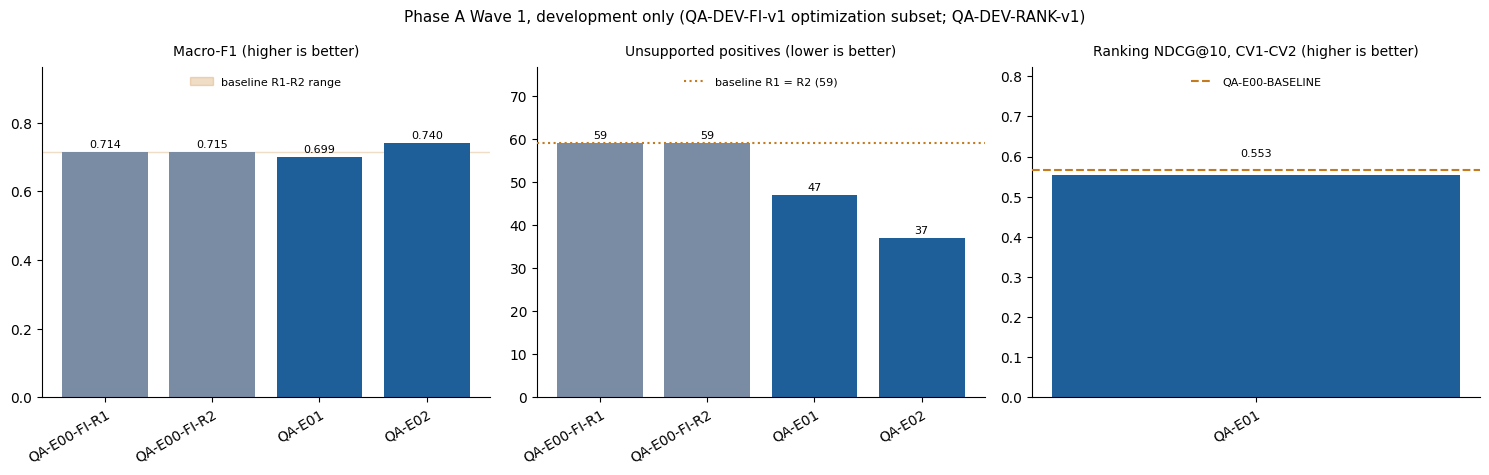

QA-E00-FI-R1  QA-E00-FI-R2  QA-E01  QA-E02
direction  field                                                          
over       education                       5             5       4       3
           knowledge_area                 41            41      41      30
           other                           3             3       3       2
           skill_tool                      2             3       4       1
           soft_skill                     16            16       9       4
unassessed experience_duration            14            14      14      14
           location                        1             0       1       1
under      certification                   0             0       1       0
           education                       1             1       2       1
           knowledge_area                 11            10      11      20
           language                        2             2       2       2
           skill_tool                      4             3       2       3
           soft_skill                      2             3       5       7

In [10]:
done = wave1[wave1['state'] == 'done'] if 'state' in wave1 else wave1.iloc[0:0]
if done.empty:
    print('No Wave 1 result yet. Run the approved experiments, then evaluate them (see docs/checkpoint_2/CP2_08).')
else:
    base_runs = done.loc[[e for e in ['QA-E00-FI-R1', 'QA-E00-FI-R2'] if e in done.index]]
    ref_ndcg = float(bm['ranking']['macro_ndcg_at_10'])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    for ax, col, title in ((axes[0], 'macro_f1', 'Macro-F1 (higher is better)'),
                           (axes[1], 'unsupported_positive', 'Unsupported positives (lower is better)'),
                           (axes[2], 'NDCG@10', 'Ranking NDCG@10, CV1-CV2 (higher is better)')):
        vals = done[col].astype(float).dropna()
        bars = ax.bar(vals.index, vals.values, zorder=2,
                      color=['#7a8ca3' if i.startswith('QA-E00') else '#1f5f99' for i in vals.index])

        # jarak label angka dari puncak bar (dalam poin): panel NDCG dibuat lebih jauh supaya lewat garis baseline
        label_pad = 12 if col == 'NDCG@10' else 2
        ax.bar_label(bars, fmt='%.0f' if col == 'unsupported_positive' else '%.3f',
                     fontsize=8, padding=label_pad, zorder=4)
        top = vals.max()

        if col != 'NDCG@10' and len(base_runs) == 2:
            lo, hi = base_runs[col].astype(float).min(), base_runs[col].astype(float).max()
            if hi > lo:
                ax.axhspan(lo, hi, color='#c47a1d', alpha=.25, zorder=1, label='baseline R1-R2 range')
            else:
                ax.axhline(lo, color='#c47a1d', ls=':', lw=1.5, zorder=3, label=f'baseline R1 = R2 ({lo:g})')
            top = max(top, hi)
        if col == 'NDCG@10':
            ax.axhline(ref_ndcg, color='#c47a1d', ls='--', zorder=3, label='QA-E00-BASELINE')
            top = max(top, ref_ndcg)

        # ruang kosong di atas bar
        headroom = 1.45 if col == 'NDCG@10' else 1.3
        ax.set_ylim(0, top * headroom)

        # posisi vertikal legend: makin besar angkanya, makin naik legend-nya
        if ax.get_legend_handles_labels()[0]:
            y_legend = 1.0
            ax.legend(frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, y_legend))

        ax.set_title(title, fontsize=10, pad=8)
        ax.tick_params(axis='x', rotation=30)
        plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Phase A Wave 1, development only (QA-DEV-FI-v1 optimization subset; QA-DEV-RANK-v1)', fontsize=11)
    fig.tight_layout()
    plt.show()

    errors = {}
    for exp in done.index:
        fx_e = load(exp, 'failures.json')
        errors[exp] = pd.DataFrame(fx_e['unit_errors']).groupby(['direction', 'field']).size() if fx_e['unit_errors'] else pd.Series(dtype=int)
    display(pd.DataFrame(errors).fillna(0).astype(int))

## 7. Best-quality configuration

**Selection rule (D-089 with amendment 1, locked in `selection_rule_v2.json` before any challenger result).** Hard gates: quote validity 1.0, unsupported positives not above the baseline, no prompt-induced failure above the baseline, ranking non-inferiority. Eligible by path A (macro-F1 at or above the practical reference, accuracy not lower, robust to leaving out one pair) or path B (unsupported positives and overclaims down by at least 10% without losing macro-F1 or accuracy, spread over at least 3 pairs), with no other regression. Exactly one provisional finalist, then its repeat `<ID>-R2`. If nothing is eligible: **KEEP BASELINE**.

The cell below only reads the locked rule and the scorecards written by `python scripts/qa_phase_a.py select`; it does not apply its own logic.

In [11]:
rule = json.loads((QA / 'selection_rule_v2.json').read_text())
display(pd.Series({'practical reference macro-F1': rule['practical_improvement_reference_macro_f1'],
                   **{f'gate: {k}': v for k, v in rule['hard_gates'].items()},
                   **{f'path B: {k}': v for k, v in rule['path_B_limits'].items()}}, name='locked rule').to_frame())
sel_file = QA / 'analysis/wave1_selection_v1.json'
if sel_file.exists():
    sel = json.loads(sel_file.read_text())
    cards = pd.DataFrame({e: {**c['gates'], 'path_A': c['path_A'], 'path_B': c['path_B'],
                              'no_other_regression': c['no_other_regression'], 'eligible': c['eligible'], **c['values']}
                          for e, c in sel['cards'].items()})
    display(cards)
    print('Provisional finalist:', sel['provisional_finalist'], '|', sel['decision'])
    rep_checks = sorted((QA / 'analysis').glob('repeat_check_*.json'))
    for r in rep_checks:
        rc = json.loads(r.read_text())
        print(r.stem, '-> passed' if rc['passed'] else '-> failed', rc['card']['values'])
else:
    print('Not selected yet: run E01-E03, evaluate them, then `python scripts/qa_phase_a.py select`.')


,locked rule
practical reference macro-F1,0.734257
gate: quote_validity,must be 1.0 with 0 invalid quotes
gate: unsupported_positive_max,59
gate: prompt_induced_failed_pairs_max,baseline max (no worsening); transient failure...
gate: ranking_p_at_5_min,0.7
gate: ranking_ndcg_at_10_min,0.547344
path B: unsupported_positive_max,53
path B: overclaim_max,60


,QA-E01,QA-E02
quote_validity_1,True,True
unsupported_not_worse,True,True
prompt_failures_not_worse,True,True
no_unrecovered_transient,True,True
ranking_p5_not_lower,True,NaN
ranking_ndcg_within_0_02,True,NaN
path_A,False,True
path_B,False,True
no_other_regression,True,False
eligible,False,False


Provisional finalist: None | no eligible challenger: keep the baseline (prompt v1.1); confirmation stays sealed


## 8. Confirmation

**Why:** a finalist was chosen on the optimization subset, so it must be checked on pairs it never saw. The confirmation subset of QA-DEV-FI-v1 (other jobs, same CVs) stays sealed until exactly one finalist is recorded, shows no per-item result, and is used once, with new experiment IDs for the baseline and each finalist. A prompt changed after this step gets a new ID and needs new confirmation data.

In [12]:
conf = registry[registry['experiment_id'].str.contains('CONF')]
display(conf if not conf.empty else 'No confirmation run yet (planned after Wave 1 review).')

'No confirmation run yet (planned after Wave 1 review).'

## 9. Limitations

- Development data only: two synthetic CVs (CV1-CV2). Ranking can only move inside the analyzed top 10, so it is a weak signal.
- The development references are not independent human ground truth: gap_v2 labels are model-draft-assisted and accepted by Dion (D-085); the anchor labels are model drafts reviewed with delegated QA (counts in `benchmark_v1/provenance.json`). If a draft model shares a family with the matcher, correlated model preferences can inflate agreement; not measured.
- Results measure primary GPT-6 Sol prompt behavior without the Luna fallback, not production fallback reliability.
- One run per challenger (except QA-E03-R); the baseline noise band comes from two runs only.
- Durations are never verified in this setup, so duration units stay unclear for every prompt (same for all, but it caps accuracy).
- Several prompts were tried on the same optimization subset, so the winner is optimistic there; that is why the confirmation subset exists.
- Not measured: wrong CV section (no section field in the output), human review of new unit errors.

## 10. Phase A conclusion

**Did quality really go up?** Read from the selection file and the conclusion file below, not from this text. QA-E02 is shown as a precision/recall trade-off: better precision on positive claims, more missed true evidence.

,experiment_id,decision,decision_reason
0,QA-E00-BASELINE,KEEP BASELINE (Phase A final),No challenger eligible under selection_rule_v2...


Final decision: KEEP BASELINE | QA-E00-BASELINE (prompt v1.1, D-087)


,macro_f1,accuracy,overclaim,underclaim,unsupported_positive
baseline_mean,0.7143,0.753,67.5,19.5,59.0
qa_e02,0.7397,0.7859,40.0,33.0,37.0
reading,Higher precision on positive claims (MATCH F1 ...,Higher precision on positive claims (MATCH F1 ...,Higher precision on positive claims (MATCH F1 ...,Higher precision on positive claims (MATCH F1 ...,Higher precision on positive claims (MATCH F1 ...


,paid (USD)
qa_phase_a_w1_qa-e00-fi-r1,0.503653
qa_phase_a_w1_qa-e00-fi-r2,0.372558
qa_phase_a_w1_qa-e01,0.993774
qa_phase_a_w1_qa-e02,0.504891


Phase A total US$2.376; avoided by adaptive stopping about US$3.41 (upper 4.62)


,estimate_usd,upper_estimate_usd
"QA-E02 Stage B (ranking, 19 calls)",0.5337,0.7230
QA-E03 Stage A + B (39 calls),1.0937,1.4818
finalist repeat <ID>-R2 (20 calls),0.5618,0.7611
confirmation baseline + finalist (44 calls),1.2235,1.6577


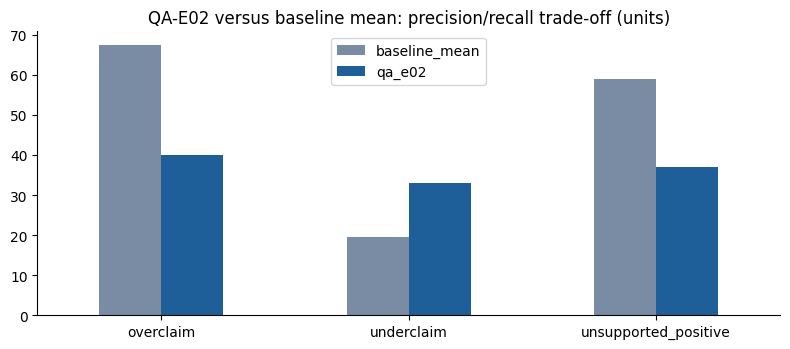

Future hypothesis: QA-H04 (Phase A2, not created, not run) - Keep the stricter direct-evidence behaviour of QA-E02 (fewer unsupported positives and overclaims) while reducing its underclaims: the neighbouring-evidence check should apply to named tools, frameworks and listed components, while a CV sentence that shows applied use of a knowledge area in work, project or study stays MATCH, and related-but-partial evidence stays PARTIAL instead of NO_MATCH.
Claim boundary: post-test development optimization, not an improved held-out result.


In [13]:
sel = registry[registry['status'] == 'selected']
display(sel[['experiment_id', 'decision', 'decision_reason']])
cfile = QA / 'analysis/phase_a_conclusion_v1.json'
if cfile.exists():
    concl = json.loads(cfile.read_text())
    print('Final decision:', concl['decision'], '|', concl['selected'])
    display(pd.DataFrame(concl['e02_trade_off']).T)
    cost = pd.Series(concl['cost']['phase_a_runs_usd'])
    display(pd.DataFrame({'paid (USD)': cost}))
    print(f"Phase A total US${concl['cost']['phase_a_total_usd']:.3f}; avoided by adaptive stopping about US${concl['avoided_estimate_usd']:.2f} (upper {concl['avoided_upper_usd']:.2f})")
    display(pd.DataFrame(concl['adaptive_stopping_avoided']).T)
    fig, ax = plt.subplots(figsize=(8, 3.6))
    t = pd.DataFrame(concl['e02_trade_off']).T[['overclaim', 'underclaim', 'unsupported_positive']]
    t.T.plot.bar(ax=ax, color=['#7a8ca3', '#1f5f99']); ax.set_title('QA-E02 versus baseline mean: precision/recall trade-off (units)')
    ax.spines[['top', 'right']].set_visible(False); ax.tick_params(axis='x', rotation=0)
    fig.tight_layout(); plt.show()
    print('Future hypothesis:', concl['future_hypothesis']['id'], '-', concl['future_hypothesis']['statement'])
print('Claim boundary: post-test development optimization, not an improved held-out result.')
